In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
from skimage import io, measure, transform
from scipy.ndimage import zoom
import nibabel as nib
from tqdm import tqdm

In [2]:
#pasta onde vamos salvar as imagens anotadas
export_root = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_annotated"

# pastas onde temos as imagens coletadas
img_dir_train= r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train"
img_dir_val = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\val"

# pastas onde temos as máscaras
mask_dir_train = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw"
mask_dir_val = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\val_masks\raw"

# pasta com as anotações em NIfTI
nii_dir_train = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\train_segmentadas"
nii_dir_val = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\val_segmentadas"

In [3]:
from pathlib import Path

print("DIRS:")
print("export_root  ->", export_root)
print("img_dir_train->", img_dir_train)
print("mask_dir_train->", mask_dir_train)
print("nii_dir_train ->", nii_dir_train)

img_dir_train = Path(img_dir_train)
mask_dir_train = Path(mask_dir_train)  # <-- pasta RAW
nii_dir_train  = Path(nii_dir_train)

imgs  = sorted(img_dir_train.glob("*.bmp"))
masks = sorted(mask_dir_train.glob("*.png"))
niis  = sorted(nii_dir_train.glob("*.nii.gz"))

print("\nCOUNTS:")
print("BMPs :", len(imgs))
print("RAWs :", len(masks))
print("NIIs :", len(niis))

print("\nSAMPLES:")
print("BMP :", imgs[0].name if imgs else "—")
print("RAW :", masks[0].name if masks else "—")
print("NII :", niis[0].name if niis else "—")


DIRS:
export_root  -> C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_annotated
img_dir_train-> C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train
mask_dir_train-> C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw
nii_dir_train -> C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\train_segmentadas

COUNTS:
BMPs : 221
RAWs : 221
NIIs : 221

SAMPLES:
BMP : 2022_03_21_11_02_58_05.bmp
RAW : 2022_03_21_11_02_58_05_masks_raw.png
NII : 2022_03_21_11_02_58_05.nii.gz


In [4]:
from pathlib import Path
import numpy as np
import nibabel as nib

nii_dir_train = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\train_segmentadas")

samples = sorted(nii_dir_train.glob("*.nii.gz"))[:3]
for p in samples:
    print("\n=== ", p.name, "===")
    try:
        nif = nib.load(str(p))
        try:
            arrA = np.asanyarray(nif.dataobj)
            print("asanyarray -> type:", type(arrA), "dtype:", getattr(arrA, "dtype", None), "shape:", getattr(arrA, "shape", None), "size:", getattr(arrA, "size", None))
        except Exception as e:
            print("asanyarray -> EXC:", repr(e))
        try:
            arrB = nif.get_fdata(dtype=np.float32)
            print("get_fdata  -> type:", type(arrB), "dtype:", getattr(arrB, "dtype", None), "shape:", getattr(arrB, "shape", None), "max:", np.max(arrB))
        except Exception as e:
            print("get_fdata  -> EXC:", repr(e))
    except Exception as e:
        print("nib.load EXC:", repr(e))



===  2022_03_21_11_02_58_05.nii.gz ===
asanyarray -> type: <class 'numpy.ndarray'> dtype: int16 shape: (2048, 1088, 11) size: 24510464
get_fdata  -> type: <class 'numpy.ndarray'> dtype: float32 shape: (2048, 1088, 11) max: 1.0

===  2022_03_21_11_02_58_14.nii.gz ===
asanyarray -> type: <class 'numpy.ndarray'> dtype: int16 shape: (2048, 1088, 1) size: 2228224
get_fdata  -> type: <class 'numpy.ndarray'> dtype: float32 shape: (2048, 1088, 1) max: 1.0

===  2022_03_21_11_02_58_22.nii.gz ===
asanyarray -> type: <class 'numpy.ndarray'> dtype: [('R', 'u1'), ('G', 'u1'), ('B', 'u1')] shape: (2048, 1088, 1) size: 2228224
get_fdata  -> EXC: DTypePromotionError("The DTypes <class 'numpy.dtypes.VoidDType'> and <class 'numpy.dtypes.Float32DType'> do not have a common DType. For example they cannot be stored in a single array unless the dtype is `object`.")


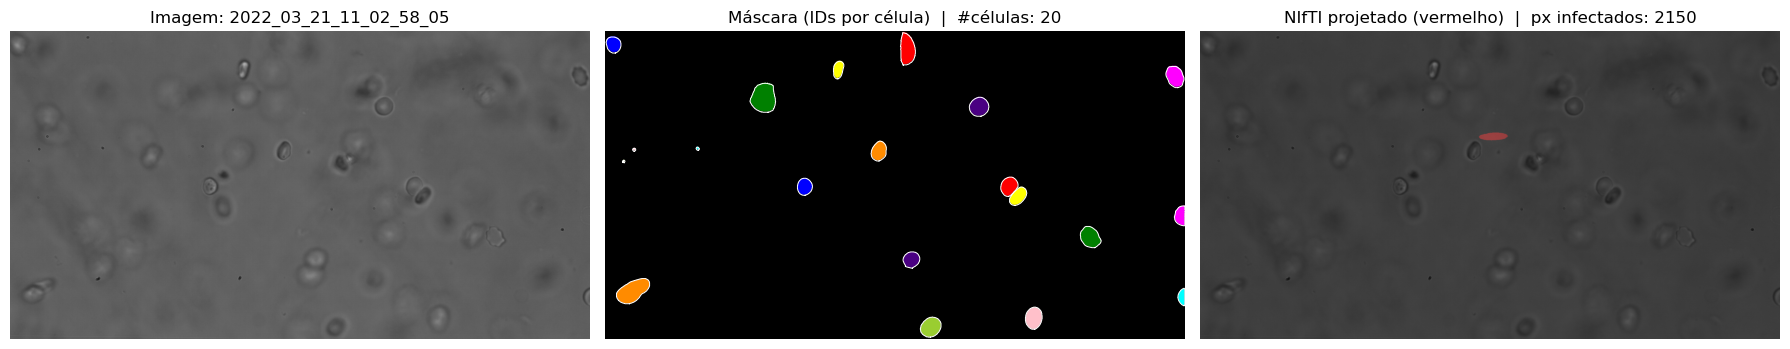

In [5]:
# === VISUALIZAÇÃO: imagem + máscara (IDs) + NIfTI (infectadas) ===
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as iio
from skimage import measure, color
import nibabel as nib
from scipy.ndimage import zoom

# --------- ajuste estes caminhos uma vez ---------
img_dir   = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train")
mask_dir  = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw")
nii_dir   = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\train_segmentadas")

# escolha um arquivo pelo nome-base (sem extensão)
stem = "2022_03_21_11_02_58_05"

# --------- helpers ---------
def load_img_rgb(p):   # usa PIL para evitar issues com BMP indexado
    return np.array(Image.open(p).convert("RGB"), dtype=np.uint8)

def load_mask_ids(p):  # usa imageio preservando inteiros
    m = iio.imread(p)
    if m.ndim == 3: m = m[...,0]
    return m.astype(np.int32)

def load_nii_bin(nii_path, target_shape):
    nif = nib.load(str(nii_path))
    arr = nif.get_fdata(dtype=np.float32)
    # colapsa 3D -> 2D (pega qualquer pixel positivo em qualquer slice)
    if arr.ndim == 3:
        arr = np.max(arr, axis=-1)
    arr = (arr > 0).astype(np.uint8)
    if arr.shape != target_shape:
        factors = (target_shape[0]/arr.shape[0], target_shape[1]/arr.shape[1])
        arr = zoom(arr, zoom=factors, order=0)
        arr = (arr > 0.5).astype(np.uint8)
    return arr

# --------- carrega arquivos ---------
img_path  = img_dir / f"{stem}.bmp"
mask_path = next(iter(mask_dir.glob(f"{stem}*raw*.png")), mask_dir / f"{stem}_masks_raw.png")
nii_path  = nii_dir / f"{stem}.nii.gz"

img  = load_img_rgb(img_path)
mask = load_mask_ids(mask_path)
inf  = load_nii_bin(nii_path, target_shape=mask.shape)

# sanity checks
assert img.shape[:2] == mask.shape == inf.shape, f"Shapes diferentes: img {img.shape[:2]}, mask {mask.shape}, nii {inf.shape}"
num_cells   = int(mask.max())
infected_px = int((inf>0).sum())

# contornos das células (para desenhar por cima)
contours = measure.find_contours(mask, level=0.5)

# overaly do infectado (vermelho semitransparente)
overlay = img.copy().astype(np.float32)/255.0
overlay_inf = np.zeros_like(overlay)
overlay_inf[...,0] = inf  # canal R
alpha = 0.35
overlay = (1-alpha)*overlay + alpha*overlay_inf
overlay = np.clip(overlay, 0, 1)

# máscara colorida por rótulo (apenas para visualizar labels)
mask_rgb = color.label2rgb(mask, bg_label=0, bg_color=(0,0,0), image=None, kind='overlay')

# --------- plots ---------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax0, ax1, ax2 = axes

ax0.imshow(img)
ax0.set_title(f"Imagem: {stem}")
ax0.axis('off')

ax1.imshow(mask_rgb)
for c in contours:
    ax1.plot(c[:,1], c[:,0], linewidth=0.7, color='white')
ax1.set_title(f"Máscara (IDs por célula)  |  #células: {num_cells}")
ax1.axis('off')

ax2.imshow(overlay)
ax2.set_title(f"NIfTI projetado (vermelho)  |  px infectados: {infected_px}")
ax2.axis('off')

plt.tight_layout()
plt.show()


NIFTI annotation


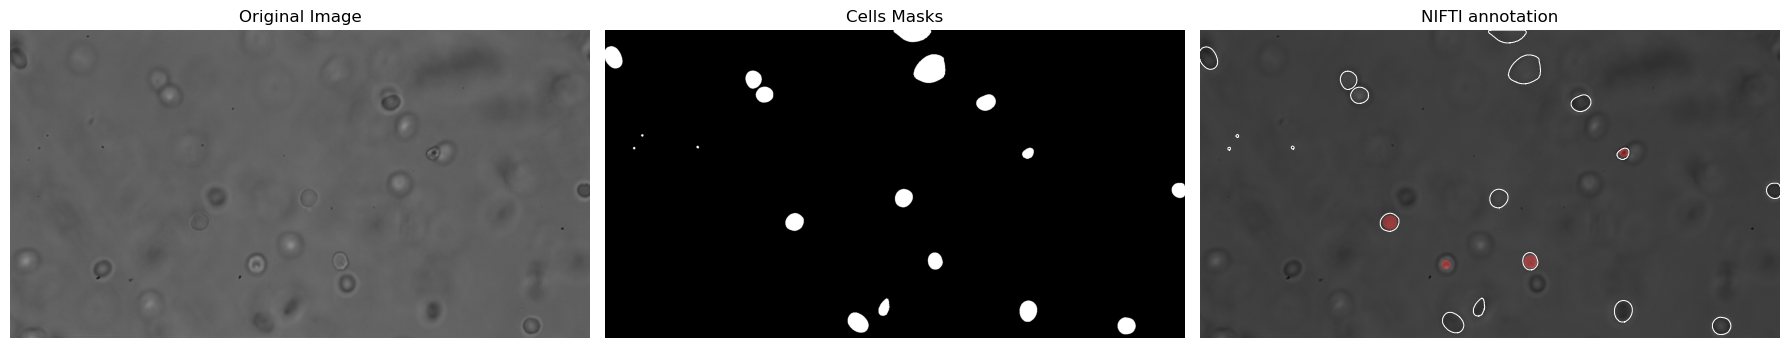

In [2]:
# ====== BUSCA AUTOMÁTICA DE SLICE + ORIENTAÇÃO PARA O NIFTI (FIX) ======
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as iio
import nibabel as nib
from skimage import measure
from scipy.ndimage import zoom

# ---- paths ----
img_dir = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train")
mask_dir = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw")
nii_dir  = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_nii\train_segmentadas")
stem = "2022_03_21_11_02_59_40"

# ---- loaders ----
def load_img_rgb(p):   return np.array(Image.open(p).convert("RGB"), dtype=np.uint8)
def load_mask_ids(p):
    m = iio.imread(p)
    if m.ndim == 3: m = m[...,0]
    return m.astype(np.int32)

img  = load_img_rgb(img_dir/f"{stem}.bmp")
mask = load_mask_ids(next(iter(mask_dir.glob(f"{stem}*raw*.png")), mask_dir/f"{stem}_masks_raw.png"))
cell_union = (mask>0).astype(np.uint8)
H, W = mask.shape

nif   = nib.load(str(nii_dir/f"{stem}.nii.gz"))
arr3d = nif.get_fdata(dtype=np.float32)  # (H,W,Z) ou (W,H,Z)

def bin_slice(sl): return (sl>0).astype(np.uint8)

def candidates(a2d):
    return [
        ("id",           a2d),
        ("rot90",        np.rot90(a2d, 1)),
        ("rot180",       np.rot90(a2d, 2)),
        ("rot270",       np.rot90(a2d, 3)),
        ("transpose",    a2d.T),
        ("flipud",       np.flipud(a2d)),
        ("fliplr",       np.fliplr(a2d)),
        ("rot90+fliplr", np.fliplr(np.rot90(a2d,1))),
        ("rot90+flipud", np.flipud(np.rot90(a2d,1))),
    ]

best = {"score": -1, "k": None, "name": None, "res": None}

Z = arr3d.shape[-1] if arr3d.ndim==3 else 1
for k in range(Z):
    sl = arr3d[..., k] if arr3d.ndim==3 else arr3d
    sl = bin_slice(sl)

    # reamostra para (H,W)
    if sl.shape != (H,W):
        sl = zoom(sl, zoom=(H/sl.shape[0], W/sl.shape[1]), order=0)

    for name, cand in candidates(sl):
        # se a transf mudou o shape, reamostra de novo
        if cand.shape != (H,W):
            cand = zoom(cand, zoom=(H/cand.shape[0], W/cand.shape[1]), order=0)

        cand_bin = (cand>0).astype(np.uint8)
        inter = np.count_nonzero((cand_bin==1) & (cell_union==1))  # <<< FIX
        if inter > best["score"]:
            best.update(score=int(inter), k=k, name=name, res=cand_bin)

print(f"NIFTI annotation")

# --- visualização do melhor overlay ---
infected = best["res"].astype(np.uint8)
overlay  = img.astype(np.float32)/255.0
overlay_inf = np.zeros_like(overlay, dtype=np.float32)
overlay_inf[...,0] = infected  # canal R
alpha = 0.35
overlay = np.clip((1-alpha)*overlay + alpha*overlay_inf, 0, 1)

contours = measure.find_contours(mask, level=0.5)

fig, ax = plt.subplots(1,3, figsize=(18,6))
ax[0].imshow(img); ax[0].set_title("Original Image"); ax[0].axis("off")
ax[1].imshow(mask>0, cmap="gray"); ax[1].set_title("Cells Masks"); ax[1].axis("off")
ax[2].imshow(overlay)
for c in contours: ax[2].plot(c[:,1], c[:,0], color="white", linewidth=0.7)
ax[2].set_title(f"NIFTI annotation")
ax[2].axis("off")
plt.tight_layout(); plt.show()


Melhor slice: 0 | transformação: transpose | interseção (px): 1800


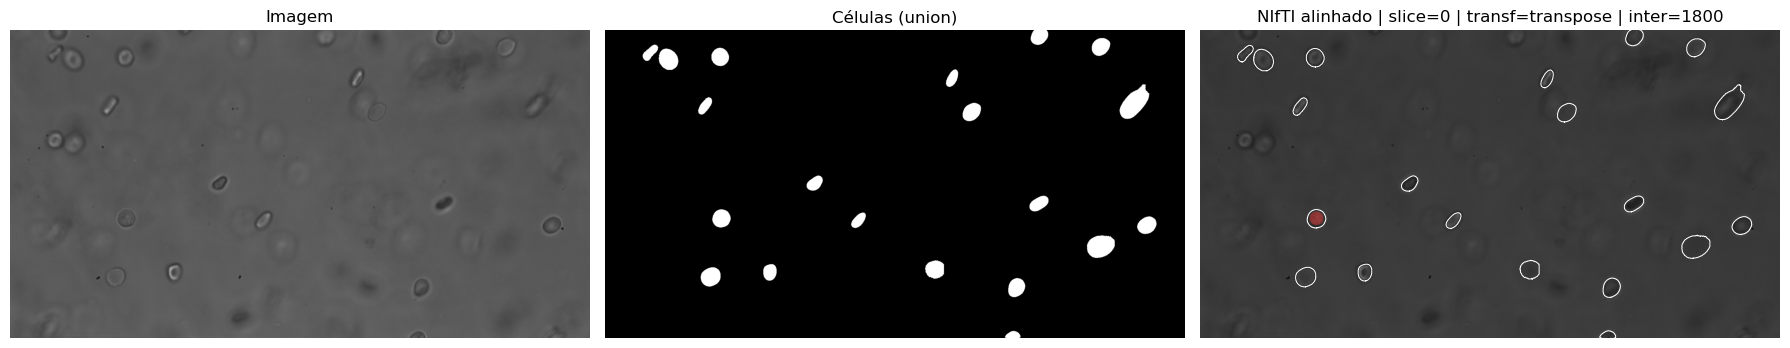

In [7]:
# ====== BUSCA AUTOMÁTICA DE SLICE + ORIENTAÇÃO PARA O NIFTI (FIX) ======
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as iio
import nibabel as nib
from skimage import measure
from scipy.ndimage import zoom

# ---- paths ----
img_dir = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train")
mask_dir = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw")
nii_dir  = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\train_segmentadas")
stem = "2022_03_21_11_02_58_14"

# ---- loaders ----
def load_img_rgb(p):   return np.array(Image.open(p).convert("RGB"), dtype=np.uint8)
def load_mask_ids(p):
    m = iio.imread(p)
    if m.ndim == 3: m = m[...,0]
    return m.astype(np.int32)

img  = load_img_rgb(img_dir/f"{stem}.bmp")
mask = load_mask_ids(next(iter(mask_dir.glob(f"{stem}*raw*.png")), mask_dir/f"{stem}_masks_raw.png"))
cell_union = (mask>0).astype(np.uint8)
H, W = mask.shape

nif   = nib.load(str(nii_dir/f"{stem}.nii.gz"))
arr3d = nif.get_fdata(dtype=np.float32)  # (H,W,Z) ou (W,H,Z)

def bin_slice(sl): return (sl>0).astype(np.uint8)

def candidates(a2d):
    return [
        ("id",           a2d),
        ("rot90",        np.rot90(a2d, 1)),
        ("rot180",       np.rot90(a2d, 2)),
        ("rot270",       np.rot90(a2d, 3)),
        ("transpose",    a2d.T),
        ("flipud",       np.flipud(a2d)),
        ("fliplr",       np.fliplr(a2d)),
        ("rot90+fliplr", np.fliplr(np.rot90(a2d,1))),
        ("rot90+flipud", np.flipud(np.rot90(a2d,1))),
    ]

best = {"score": -1, "k": None, "name": None, "res": None}

Z = arr3d.shape[-1] if arr3d.ndim==3 else 1
for k in range(Z):
    sl = arr3d[..., k] if arr3d.ndim==3 else arr3d
    sl = bin_slice(sl)

    # reamostra para (H,W)
    if sl.shape != (H,W):
        sl = zoom(sl, zoom=(H/sl.shape[0], W/sl.shape[1]), order=0)

    for name, cand in candidates(sl):
        # se a transf mudou o shape, reamostra de novo
        if cand.shape != (H,W):
            cand = zoom(cand, zoom=(H/cand.shape[0], W/cand.shape[1]), order=0)

        cand_bin = (cand>0).astype(np.uint8)
        inter = np.count_nonzero((cand_bin==1) & (cell_union==1))  # <<< FIX
        if inter > best["score"]:
            best.update(score=int(inter), k=k, name=name, res=cand_bin)

print(f"Melhor slice: {best['k']} | transformação: {best['name']} | interseção (px): {best['score']}")

# --- visualização do melhor overlay ---
infected = best["res"].astype(np.uint8)
overlay  = img.astype(np.float32)/255.0
overlay_inf = np.zeros_like(overlay, dtype=np.float32)
overlay_inf[...,0] = infected  # canal R
alpha = 0.35
overlay = np.clip((1-alpha)*overlay + alpha*overlay_inf, 0, 1)

contours = measure.find_contours(mask, level=0.5)

fig, ax = plt.subplots(1,3, figsize=(18,6))
ax[0].imshow(img); ax[0].set_title("Imagem"); ax[0].axis("off")
ax[1].imshow(mask>0, cmap="gray"); ax[1].set_title("Células (union)"); ax[1].axis("off")
ax[2].imshow(overlay)
for c in contours: ax[2].plot(c[:,1], c[:,0], color="white", linewidth=0.7)
ax[2].set_title(f"NIfTI alinhado | slice={best['k']} | transf={best['name']} | inter={best['score']}")
ax[2].axis("off")
plt.tight_layout(); plt.show()


In [8]:
# ============================================
# Exportar crops (infected / uninfected) para Swin
# Versão blindada: OpenCV para resize + NIfTI robusto
# Suporta NIfTI com dtype estruturado (RGB por voxel)
# Compatível com NumPy 2.0 (usa np.asarray em vez de copy=False)
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import imageio.v2 as iio
import nibabel as nib
from skimage import measure   # apenas para regionprops
from tqdm import tqdm
import cv2

# -------------------- HELPERS --------------------
def load_img_rgb(path):
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)

def load_mask_ids(path):
    m = iio.imread(path)
    if m.ndim == 3:
        m = m[..., 0]
    return m.astype(np.int32)

def _sanitize_u8(arr):
    if arr is None:
        return None
    if arr.dtype == np.void or arr.dtype == object:
        try:
            arr = np.array(arr.tolist())
        except Exception:
            arr = np.asarray(arr)
    if not np.issubdtype(arr.dtype, np.integer):
        arr = np.asarray(arr, dtype=np.float32)
        arr = np.clip(arr, 0, 255)
    return arr.astype(np.uint8, copy=False)

def _resize_u8_cv(img_u8, out_wh, interp=cv2.INTER_AREA):
    img_u8 = _sanitize_u8(img_u8)
    ow, oh = out_wh  # (width, height)
    return cv2.resize(img_u8, (ow, oh), interpolation=interp).astype(np.uint8, copy=False)

def _resize_bin_cv(bin_u8, out_wh):
    return _resize_u8_cv(bin_u8, out_wh, interp=cv2.INTER_NEAREST)

def _crop_with_padding(img, bbox, pad=6):
    y0, x0, y1, x1 = bbox
    H, W = img.shape[:2]
    y0 = max(y0 - pad, 0); x0 = max(x0 - pad, 0)
    y1 = min(y1 + pad, H); x1 = min(x1 + pad, W)
    return img[y0:y1, x0:x1]

# -------------------- NIFTI ALIGN --------------------
def _candidates(a2d):
    return [
        ("id",           a2d),
        ("rot90",        np.rot90(a2d, 1)),
        ("rot180",       np.rot90(a2d, 2)),
        ("rot270",       np.rot90(a2d, 3)),
        ("transpose",    a2d.T),
        ("flipud",       np.flipud(a2d)),
        ("fliplr",       np.fliplr(a2d)),
        ("rot90+fliplr", np.fliplr(np.rot90(a2d, 1))),
        ("rot90+flipud", np.flipud(np.rot90(a2d, 1))),
    ]

def _best_infected_map_from_nii_cv(nii_path, target_shape, cell_union,
                                   force_slice=None, force_transform=None,
                                   _debug_first_fails=5):
    """
    Retorna (infected_map_bin, best_slice, best_transform, score, status)
    status ∈ {"ok","empty","failed"}
    """
    H, W = target_shape
    status = "ok"
    dbg_reason = None

    # --- carregar com múltiplas estratégias (compatível NumPy 2.0) ---
    arr3d = None
    try:
        nif = nib.load(str(nii_path))

        # 1) asanyarray
        try:
            arr3d = np.asanyarray(nif.dataobj)
        except Exception as e:
            dbg_reason = f"asanyarray EXC {e}"
            arr3d = None

        # 2) get_fdata se veio ruim/estranho
        if arr3d is None or getattr(arr3d, "dtype", None) in (None, np.void, object):
            try:
                arr3d = nif.get_fdata(dtype=np.float32)
            except Exception as e:
                dbg_reason = f"get_fdata EXC {e}"
                arr3d = None

        # 3) tolist -> asarray (quando dtype é void/object)
        if arr3d is not None and (arr3d.dtype == np.void or arr3d.dtype == object):
            try:
                arr3d = np.asarray(arr3d.tolist(), dtype=np.float32)
            except Exception as e:
                dbg_reason = f"tolist EXC {e}"
                arr3d = None

        # 4) último recurso: asarray(dataobj)
        if arr3d is None:
            try:
                arr3d = np.asarray(nif.dataobj, dtype=np.float32)
            except Exception as e:
                dbg_reason = f"array(dataobj) EXC {e}"
                arr3d = None

    except Exception as e:
        dbg_reason = f"nib.load EXC {e}"
        arr3d = None

    # falhou geral
    if arr3d is None or arr3d.size == 0:
        status = "failed"
        if _best_infected_map_from_nii_cv.__dict__.get("_fails", 0) < _debug_first_fails:
            print(f"[WARN] NIfTI FAIL {nii_path.name} :: {dbg_reason}")
            _best_infected_map_from_nii_cv.__dict__["_fails"] = _best_infected_map_from_nii_cv.__dict__.get("_fails", 0) + 1
        return np.zeros((H, W), dtype=np.uint8), -1, "NA", 0, status

    # --- NORMALIZAÇÃO (inclui dtype estruturado RGB) ---
    if hasattr(arr3d, "dtype") and arr3d.dtype.fields is not None:
        # dtype estruturado, ex.: [('R','u1'),('G','u1'),('B','u1')]
        arr_u8 = arr3d.view(np.uint8).reshape(arr3d.shape + (arr3d.dtype.itemsize,))
        arr3d  = arr_u8.max(axis=-1).astype(np.float32, copy=False)
    elif arr3d.dtype != np.float32:
        arr3d = np.asarray(arr3d, dtype=np.float32)

    # remove singleton final (H,W,1) -> (H,W)
    if arr3d.ndim >= 3 and arr3d.shape[-1] == 1:
        arr3d = np.squeeze(arr3d, axis=-1)

    # sem infecção
    if np.max(arr3d) <= 0:
        status = "empty"
        return np.zeros((H, W), dtype=np.uint8), 0, "id", 0, status

    # --- seleção de slice + transformação ---
    Z = arr3d.shape[-1] if arr3d.ndim == 3 else 1
    best = {"score": -1, "k": None, "name": None, "res": None}
    k_range = [force_slice] if force_slice is not None else range(Z)

    def _bin(x): return (x > 0).astype(np.uint8)

    for k in k_range:
        sl = arr3d[..., k] if arr3d.ndim == 3 else arr3d
        sl = _bin(sl)

        if sl.shape != (H, W):
            sl = _resize_bin_cv(sl, (W, H))  # cv2: (width,height)

        cand_list = _candidates(sl)
        if force_transform is not None:
            cand_list = [(n, a) for (n, a) in cand_list if n == force_transform]
            if not cand_list:
                raise ValueError(f"Transformação '{force_transform}' não reconhecida.")

        for name, cand in cand_list:
            if cand.shape != (H, W):
                cand = _resize_bin_cv(cand, (W, H))
            cand_bin = _bin(cand)
            inter = np.count_nonzero((cand_bin == 1) & (cell_union == 1))
            if inter > best["score"]:
                best.update(score=int(inter), k=k, name=name, res=cand_bin)

    if best["res"] is None:
        status = "failed"
        if _best_infected_map_from_nii_cv.__dict__.get("_fails", 0) < _debug_first_fails:
            print(f"[WARN] NIfTI FAIL (no candidate) {nii_path.name}")
            _best_infected_map_from_nii_cv.__dict__["_fails"] = _best_infected_map_from_nii_cv.__dict__.get("_fails", 0) + 1
        return np.zeros((H, W), dtype=np.uint8), -1, "NA", 0, status

    return best["res"].astype(np.uint8), int(best["k"]), str(best["name"]), int(best["score"]), status

# -------------------- PIPELINE --------------------
def export_cells_for_swin_auto(
    img_dir, mask_raw_dir, nii_dir, out_dir,
    split_name="train",
    resize_to=(224, 224),
    frac_thresh=0.10,
    force_slice=None,
    force_transform=None,
    skip_existing=True,
):
    img_dir      = Path(img_dir)
    mask_raw_dir = Path(mask_raw_dir)
    nii_dir      = Path(nii_dir)
    out_dir      = Path(out_dir)

    out_pos = out_dir / split_name / "infected"
    out_neg = out_dir / split_name / "uninfected"
    out_pos.mkdir(parents=True, exist_ok=True)
    out_neg.mkdir(parents=True, exist_ok=True)

    imgs = sorted(img_dir.glob("*.bmp"))
    print(f"{len(imgs)} imagens encontradas em {img_dir}")

    records, decisions = [], []
    missing_mask, missing_nii, empty_masks = [], [], []
    count_ok = count_empty = count_failed = 0

    for img_path in tqdm(imgs):
        stem = img_path.stem

        cand_masks = list(mask_raw_dir.glob(f"{stem}*raw*.png")) or list(mask_raw_dir.glob(f"{stem}*.png"))
        if not cand_masks:
            missing_mask.append(stem); continue
        mask_path = cand_masks[0]

        nii_path = nii_dir / f"{stem}.nii.gz"
        if not nii_path.exists():
            missing_nii.append(stem); continue

        img  = _sanitize_u8(load_img_rgb(img_path))
        mask = load_mask_ids(mask_path)
        if np.max(mask) == 0:
            empty_masks.append(stem); continue

        H, W = mask.shape
        cell_union = (mask > 0).astype(np.uint8)

        infected_map, k, transf, score, nii_status = _best_infected_map_from_nii_cv(
            nii_path, (H, W), cell_union,
            force_slice=force_slice, force_transform=force_transform
        )
        if nii_status == "ok":       count_ok += 1
        elif nii_status == "empty":  count_empty += 1
        else:                        count_failed += 1

        decisions.append({
            "image": stem,
            "slice": int(k),
            "transform": str(transf),
            "score": int(score),
            "nii_status": nii_status
        })

        for r in measure.regionprops(mask):
            rid = r.label
            region = (mask == rid)
            inter  = np.count_nonzero(region & (infected_map > 0))
            frac_on_cell = inter / max(region.sum(), 1)

            y0, x0, y1, x1 = r.bbox
            crop = _crop_with_padding(img, (y0, x0, y1, x1), pad=6)
            if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
                continue

            try:
                crop = _resize_u8_cv(crop, resize_to)
            except Exception as e:
                print(f"[WARN] resize falhou em {stem} cell {rid}: dtype={crop.dtype}, shape={crop.shape} | {e}")
                continue

            label = 1 if frac_on_cell >= frac_thresh else 0
            out_path = (out_pos if label == 1 else out_neg) / f"{stem}_cell{rid:04d}.png"
            if not (skip_existing and out_path.exists()):
                iio.imwrite(out_path, crop)

            records.append({
                "split": split_name,
                "image": stem,
                "cell_id": int(rid),
                "bbox": (int(y0), int(x0), int(y1), int(x1)),
                "frac_on_cell": float(frac_on_cell),
                "label": int(label),
                "path": str(out_path),
                "best_slice": int(k),
                "best_transform": str(transf),
                "align_score": int(score),
                "nii_status": nii_status,
            })

    out_dir.mkdir(parents=True, exist_ok=True)
    df  = pd.DataFrame(records)
    dec = pd.DataFrame(decisions)
    (out_dir / f"cells_{split_name}.csv").write_text(df.to_csv(index=False))
    (out_dir / f"alignment_{split_name}.csv").write_text(dec.to_csv(index=False))

    print("Resumo classes:", df['label'].value_counts(dropna=False).to_dict() if len(df) else "sem registros")
    if missing_mask: print(f"Sem máscara para {len(missing_mask)} imagens (ex.: {missing_mask[:3]})")
    if missing_nii:  print(f"Sem NIfTI para {len(missing_nii)} imagens (ex.: {missing_nii[:3]})")
    if empty_masks:  print(f"Máscaras vazias: {len(empty_masks)} (ex.: {empty_masks[:3]})")
    print(f"NIfTI status → ok: {count_ok} | empty(sem infecção): {count_empty} | failed(corrompido): {count_failed}")

    return df, dec


In [9]:
export_root   = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_annotated"

img_dir_train  = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train"
img_dir_val    = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\val"

mask_dir_train = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw"
mask_dir_val   = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\val_masks\raw"

nii_dir_train  = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\train_segmentadas"
nii_dir_val    = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\val_segmentadas"

df_train, dec_train = export_cells_for_swin_auto(
    img_dir=img_dir_train,
    mask_raw_dir=mask_dir_train,
    nii_dir=nii_dir_train,
    out_dir=export_root,
    split_name="train",
    frac_thresh=0.10,
    #force_slice=0,                 # opcional: fixe se você já validou
    #force_transform="transpose",   # opcional
)

df_val, dec_val = export_cells_for_swin_auto(
    img_dir=img_dir_val,
    mask_raw_dir=mask_dir_val,
    nii_dir=nii_dir_val,
    out_dir=export_root,
    split_name="val",
    frac_thresh=0.10,
    #force_slice=0,
    #force_transform="transpose",
)


221 imagens encontradas em C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train


100%|██████████| 221/221 [00:59<00:00,  3.74it/s]


Resumo classes: {0: 3257, 1: 708}
NIfTI status → ok: 215 | empty(sem infecção): 6 | failed(corrompido): 0
221 imagens encontradas em C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\val


100%|██████████| 221/221 [01:05<00:00,  3.40it/s]

Resumo classes: {1: 3535, 0: 276}
NIfTI status → ok: 217 | empty(sem infecção): 4 | failed(corrompido): 0
